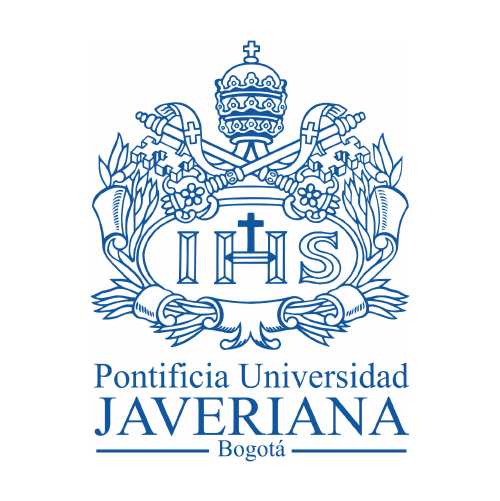!


Apache Spark - Actividad

Fecha: 21/09/2026

Autor: juan david murcia lopez

ID: 00020552313

odjetivo: Desarrollar un pipeline de Machine Learning distribuido en PySpark para clasificar especies de flores utilizando el conjunto de datos Iris, comparando el rendimiento de diferentes algoritmos de clasificación multiclase y aplicando buenas prácticas de preprocesamiento, escalado y evaluación de modelos.

descripcion: proyecto sobre pyspark.ml que aborda el flujo completo de Machine Learning usando el dataset Iris. 
IPYNB+ 1


**indice:**

* Import Libraries
* Build Spark Session
* Data Load
* Data Exploration & Preparation
* Feature Engineering
* Data Scaling
* Data Split
* Build, Train & Evaluate Model


## Importing Libraries

In [2]:
#Generic Libraries

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt

#Apache Spark Libraries
import pyspark
from pyspark.sql import SparkSession

#Apache Spark ML CLassifier Libraries
from pyspark.ml.classification import DecisionTreeClassifier,RandomForestClassifier,NaiveBayes

#Apache Spark Evaluation Library
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

#Apache Spark Features libraries
from pyspark.ml.feature import StandardScaler,StringIndexer, VectorAssembler, VectorIndexer, OneHotEncoder

#Apache Spark Pipelin Library
from pyspark.ml import Pipeline

# Apache Spark `DenseVector`
from pyspark.ml.linalg import DenseVector

#Data Split Libraries
import sklearn
from sklearn.model_selection import train_test_split


#Tabulating Data
from tabulate import tabulate

#Garbage
import gc

## Build Spark Session

- se crea la sesión de Spark , que es el punto de entrada para trabajar con Spark, configurando el nombre de la app, el clúster y los recursos

In [3]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("Apache Spark Beginner Tutorial")
         .config("spark.executor.memory", "1G")
         .config("spark.executor.cores", "4")
         .getOrCreate())

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


- se Configura el nivel de los logs de Spark en 'INFO' para ver más detalle de lo que hace internamente

In [4]:
spark.sparkContext.setLogLevel('INFO')

- **Descripción:** Muestra la versión de Spark que se está usando.

In [5]:
spark.version

'4.2.0'

## Data Load

- Carga el archivo Iris.csv como un DataFrame de Spark y lo guarda en caché para acelerar accesos futuros

In [6]:
url = "Iris.csv"

data = (
    spark.read.format("csv")
    .option("header", "true")
    .option("inferSchema", "true")
    .load(url)
)

data.cache()

DataFrame[Id: int, SepalLengthCm: double, SepalWidthCm: double, PetalLengthCm: double, PetalWidthCm: double, Species: string]

## Data Exploration & Preparation

- Cuenta el numero total de registros del dataset

In [7]:
#Total records 
data.count()

150

- Muestra el esquema del DataFrame, es decir, el nombre y tipo de dato de cada columna

In [8]:
#Data Type
data.printSchema()

root
 |-- Id: integer (nullable = true)
 |-- SepalLengthCm: double (nullable = true)
 |-- SepalWidthCm: double (nullable = true)
 |-- PetalLengthCm: double (nullable = true)
 |-- PetalWidthCm: double (nullable = true)
 |-- Species: string (nullable = true)



- **Descripción:** Muestra las primeras 5 filas del dataset.

In [9]:
#Display records
data.show(5)

+---+-------------+------------+-------------+------------+-----------+
| Id|SepalLengthCm|SepalWidthCm|PetalLengthCm|PetalWidthCm|    Species|
+---+-------------+------------+-------------+------------+-----------+
|  1|          5.1|         3.5|          1.4|         0.2|Iris-setosa|
|  2|          4.9|         3.0|          1.4|         0.2|Iris-setosa|
|  3|          4.7|         3.2|          1.3|         0.2|Iris-setosa|
|  4|          4.6|         3.1|          1.5|         0.2|Iris-setosa|
|  5|          5.0|         3.6|          1.4|         0.2|Iris-setosa|
+---+-------------+------------+-------------+------------+-----------+
only showing top 5 rows


- Agrupa los datos por la columna 'species' y cuenta cuántos registros hay de cada especie

In [10]:
#Records per Species
data.groupBy('species').count().show()

+---------------+-----+
|        species|count|
+---------------+-----+
| Iris-virginica|   50|
|    Iris-setosa|   50|
|Iris-versicolor|   50|
+---------------+-----+



- Muestra estadísticas descriptivas de los datos numericos

In [11]:
#Dataset Summary Stats
data.describe().show()

26/09/22 18:04:37 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 10:>                                                         (0 + 1) / 1]

+-------+------------------+------------------+-------------------+------------------+------------------+--------------+
|summary|                Id|     SepalLengthCm|       SepalWidthCm|     PetalLengthCm|      PetalWidthCm|       Species|
+-------+------------------+------------------+-------------------+------------------+------------------+--------------+
|  count|               150|               150|                150|               150|               150|           150|
|   mean|              75.5| 5.843333333333335| 3.0540000000000007|3.7586666666666693|1.1986666666666672|          NULL|
| stddev|43.445367992456916|0.8280661279778637|0.43359431136217375| 1.764420419952262|0.7631607417008414|          NULL|
|    min|                 1|               4.3|                2.0|               1.0|               0.1|   Iris-setosa|
|    max|               150|               7.9|                4.4|               6.9|               2.5|Iris-virginica|
+-------+------------------+----

Inorder for our model to make predictions the Species aka Label column should be a numerical value (models don't like string!). To achieve this we shall use String Indexing on the Species columns

- Convierte la columna de texto 'species' en una columna numérica ('species_indx') usando StringIndexer, ya que los modelos necesitan números en lugar de texto

In [12]:
#String Indexing the Species column
if 'species_indx' not in data.columns:
    SIndexer = StringIndexer(inputCol='species', outputCol='species_indx')
    data = SIndexer.fit(data).transform(data)

#Inspect the dataset
data.show(5)


+---+-------------+------------+-------------+------------+-----------+------------+
| Id|SepalLengthCm|SepalWidthCm|PetalLengthCm|PetalWidthCm|    Species|species_indx|
+---+-------------+------------+-------------+------------+-----------+------------+
|  1|          5.1|         3.5|          1.4|         0.2|Iris-setosa|         0.0|
|  2|          4.9|         3.0|          1.4|         0.2|Iris-setosa|         0.0|
|  3|          4.7|         3.2|          1.3|         0.2|Iris-setosa|         0.0|
|  4|          4.6|         3.1|          1.5|         0.2|Iris-setosa|         0.0|
|  5|          5.0|         3.6|          1.4|         0.2|Iris-setosa|         0.0|
+---+-------------+------------+-------------+------------+-----------+------------+
only showing top 5 rows


## Feature Engineering

The Spark model needs two columns: “label” and “features” and we are not going to do much feature engineering because we want to focus on the mechanics of training the model in Spark. 

So, creating a seperate dataframe with re-ordered columns, then defining an input data using Dense Vector. A Dense Vector is a local vector that is backed by a double array that represents its entry values. In other words, it's used to store arrays of values for use in PySpark.


- Crea un nuevo DataFrame reordenando las columnas, dejando primero la columna de la etiqueta (species_indx) y luego las características, y muestra las primeras filas.

In [13]:
from pyspark.ml.feature import VectorAssembler
#creating a seperate dataframe with re-ordered columns
df = data.select("SepalLengthCm","SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "species_indx")

#Inspect the dataframe
df.show(5)

+-------------+------------+-------------+------------+------------+
|SepalLengthCm|SepalWidthCm|PetalLengthCm|PetalWidthCm|species_indx|
+-------------+------------+-------------+------------+------------+
|          5.1|         3.5|          1.4|         0.2|         0.0|
|          4.9|         3.0|          1.4|         0.2|         0.0|
|          4.7|         3.2|          1.3|         0.2|         0.0|
|          4.6|         3.1|          1.5|         0.2|         0.0|
|          5.0|         3.6|          1.4|         0.2|         0.0|
+-------------+------------+-------------+------------+------------+
only showing top 5 rows


**Note:** Observe that the species column which is our label (aka Target) is now at beginning of the dataframe

- Usa VectorAssembler para juntar las columnas de características en una sola columna 'features', renombra 'species_indx' a 'label' y muestra el resultado

In [14]:
from pyspark.ml.feature import VectorAssembler


feature_cols = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm",
]


assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")


df_indx = (
    assembler.transform(data)
    .withColumnRenamed("species_indx", "label")
    .select("label", "features")
)


df_indx.show(5)

+-----+-----------------+
|label|         features|
+-----+-----------------+
|  0.0|[5.1,3.5,1.4,0.2]|
|  0.0|[4.9,3.0,1.4,0.2]|
|  0.0|[4.7,3.2,1.3,0.2]|
|  0.0|[4.6,3.1,1.5,0.2]|
|  0.0|[5.0,3.6,1.4,0.2]|
+-----+-----------------+
only showing top 5 rows


## Data Split

- **Corrección aplicada:** el split se hace ANTES de escalar (sobre `df_indx`, que aún no tiene `features_scaled`), para evitar fuga de datos (data leakage): el `StandardScaler` no debe conocer estadísticas del conjunto de prueba.
- Se divide en entrenamiento (80%) y prueba (20%) de forma aleatoria pero reproducible. Se sube el porcentaje de test frente al 10% original porque con solo 150 filas, un test set de ~15 registros da métricas muy inestables.

In [15]:
train_raw, test_raw = df_indx.randomSplit([0.8, 0.2], seed = 12345)

- Muestra las primeras filas del conjunto de entrenamiento (sin escalar todavía)

In [16]:
#Inspect Training Data
train_raw.show(5)

+-----+-----------------+
|label|         features|
+-----+-----------------+
|  0.0|[4.3,3.0,1.1,0.1]|
|  0.0|[4.4,2.9,1.4,0.2]|
|  0.0|[4.4,3.0,1.3,0.2]|
|  0.0|[4.4,3.2,1.3,0.2]|
|  0.0|[4.5,2.3,1.3,0.3]|
+-----+-----------------+
only showing top 5 rows


## Data Scaling

This is also known as Feature Scaling. It is a method of normalizing the features of the data. Scaling can make a difference between a weak machine learning model and a better one. 

In this tutorial we will use a Standard Scaler to scale our feature data. Apache Spark has a Standard Scaler library to do the job.

- **Corrección aplicada:** el `StandardScaler` se ajusta (`fit`) únicamente con `train_raw`, nunca con el dataset completo ni con el test set. Luego ese mismo scaler ya entrenado se usa para transformar tanto `train_raw` como `test_raw`, generando la columna `features_scaled` en ambos y evitando la fuga de información del test set hacia el entrenamiento.

In [17]:
#Initialize Standard Scaler
stdScaler = StandardScaler(inputCol="features", outputCol="features_scaled")

#Fit the Standard Scaler ONLY on the training data (avoids data leakage)
scaler = stdScaler.fit(train_raw)

#Transform train and test with the SAME fitted scaler
train_data = scaler.transform(train_raw).drop("features")
test_data  = scaler.transform(test_raw).drop("features")

- Muestra las primeras filas del conjunto de entrenamiento ya con las características escaladas

In [18]:
#Viewing the Scaled Training Data
train_data.show(5)

+-----+--------------------+
|label|     features_scaled|
+-----+--------------------+
|  0.0|[5.16955447182429...|
|  0.0|[5.28977666884346...|
|  0.0|[5.28977666884346...|
|  0.0|[5.28977666884346...|
|  0.0|[5.40999886586263...|
+-----+--------------------+
only showing top 5 rows


## Build, Train & Evaluate Model

In this step we will create multiple models, train them on our scaled dataset and then compare their accuracy.

- Crea una lista con los nombres de los modelos a comparar y una lista vacía para guardar los resultados

In [19]:
model = ['Decision Tree','Random Forest','Naive Bayes']
model_results = []

- Entrena un modelo Decision Tree, lo evalúa con los datos de prueba, la accuracy y guarda el resultado

In [20]:
# -- Decision Tree Classifier --

dtc = DecisionTreeClassifier(labelCol="label", featuresCol="features_scaled")          #instantiate the model
dtc_model = dtc.fit(train_data)                                                        #train the model
dtc_pred = dtc_model.transform(test_data)                                              #model predictions

#Evaluate the Model
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
dtc_acc = evaluator.evaluate(dtc_pred)
#print("Decision Tree Classifier Accuracy =", '{:.2%}'.format(dtc_acc))
model_results.extend([[model[0],'{:.2%}'.format(dtc_acc)]])                               #appending to list
    

- Entrena un modelo de Random Forest con 10 árboles, lo evalúa, calcula su precisión y guarda el resultado

In [21]:
# -- Random Forest Classifier --

rfc = RandomForestClassifier(labelCol="label", featuresCol="features_scaled", numTrees=10)          #instantiate the model
rfc_model = rfc.fit(train_data)                                                                     #train the model
rfc_pred = rfc_model.transform(test_data)                                                           #model predictions

#Evaluate the Model
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
rfc_acc = evaluator.evaluate(rfc_pred)
#print("Random Forest Classifier Accuracy =", '{:.2%}'.format(rfc_acc))
model_results.extend([[model[1],'{:.2%}'.format(rfc_acc)]])                                            #appending to list

- Entrena un modelo Naive Bayes, lo evalúa con los datos de prueba, calcula su precisión y guarda el resultado

In [22]:
# -- Naive Bayes Classifier --

nbc = NaiveBayes(smoothing=1.0,modelType="multinomial", labelCol="label",featuresCol="features_scaled")    #instantiate the model
nbc_model = nbc.fit(train_data)                                                                          #train the model
nbc_pred = nbc_model.transform(test_data)                                                                #model predictions

#Evaluate the Model
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
nbc_acc = evaluator.evaluate(nbc_pred)
#print("Naive Bayes Accuracy =", '{:.2%}'.format(nbc_acc))
model_results.extend([[model[2],'{:.2%}'.format(nbc_acc)]])                                            #appending to list

- Libera memoria manualmente ejecutando el recolector de basura de Python

In [23]:
#freeing memory
gc.collect()

768

Tabulating the results.

- Imprime una tabla comparando la accuracy obtenida por cada uno de los tres modelos

In [24]:
print (tabulate(model_results, headers=["Classifier Models", "Accuracy"]))

Classifier Models    Accuracy
-------------------  ----------
Decision Tree        95.24%
Random Forest        100.00%
Naive Bayes          85.71%


[['Decision Tree', '95.24%'], ['Random Forest', '100.00%'], ['Naive Bayes', '85.71%']]


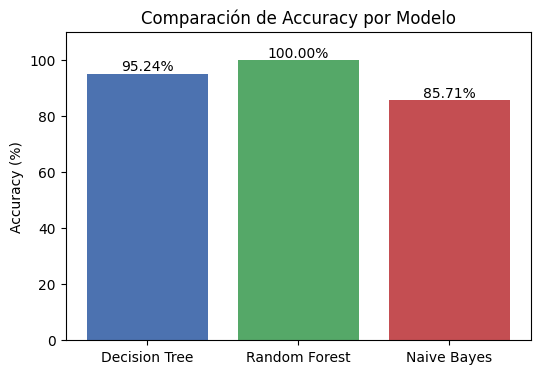

In [25]:

modelos = [row[0] for row in model_results]
accuracies = [float(row[1].strip('%')) for row in model_results]

plt.figure(figsize=(6,4))
bars = plt.bar(modelos, accuracies, color=["#4C72B0","#55A868","#C44E52"])
plt.ylabel("Accuracy (%)")
plt.ylim(0, 110)
plt.title("Comparación de Accuracy por Modelo")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f"{acc:.2f}%", ha='center')
plt.show()

## Conclusión

Este notebook implementó un flujo completo de Machine Learning distribuido con PySpark sobre el dataset Iris: se cargaron y exploraron los datos, se transformó la especie a un valor numérico, se construyó el vector de características y se escaló, se dividió el conjunto en entrenamiento y prueba, y finalmente se entrenaron y evaluaron tres modelos de clasificación (Árbol de Decisión, Random Forest y Naive Bayes). La comparación de precisión (accuracy) entre los tres algoritmos permite identificar cuál se ajusta mejor a la tarea de clasificar las especies de flores, evidenciando además cómo Spark facilita este proceso de manera escalable y distribuida.